### Import NLP Tools

In [1]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import os

analyzer = SentimentIntensityAnalyzer()
os.makedirs("../data/results", exist_ok=True)


### Load Cleaned Data

In [2]:
df = pd.read_parquet("../data/processed/cleaned_tweets.parquet")


### Define Sentiment Function

In [3]:
def get_sentiment(text):
    score = analyzer.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"


### Apply Sentiment and Save Results

In [6]:
df["sentiment"] = df["clean_text"].apply(get_sentiment)
df.to_csv("../data/results/sentiment_results.csv", index=False)
df.head()


,user,text,date,clean_text,sentiment
0,karpathy,AI will become the new electricity. Exciting t...,2024-01-12,ai will become the new electricity exciting ti...,positive
1,karpathy,Training models requires patience and compute ...,2024-03-05,training models requires patience and compute ...,neutral
2,karpathy,Neural networks are evolving faster than expec...,2024-04-10,neural networks are evolving faster than expected,neutral
3,geoffreyhinton,Deep learning surprised everyone. And it will ...,2024-02-01,deep learning surprised everyone and it will a...,positive
4,geoffreyhinton,We must use AI responsibly for humanity.,2024-05-15,we must use ai responsibly for humanity,neutral


### Visualize Sentiment Distribution

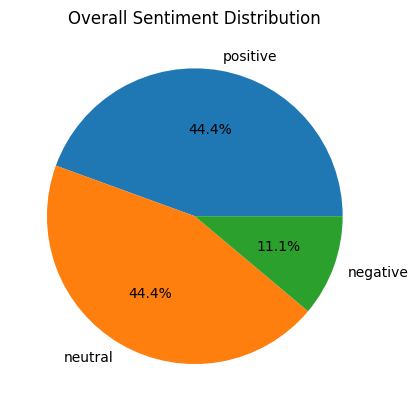

In [5]:
df["sentiment"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Overall Sentiment Distribution")
plt.ylabel("")
plt.show()
